# 04 — Manual Quantization
The purpose of this notebook is to understand exactly how quantization changes model weights by manually converting a single layer from floating point to INT8 and tracing the consequences.  This is a precursor to notebook 05, where we will use proper tooling to quantize much larger parts of the model.

The goal is not to create the best model here.  The goal is to see exactly where precision is lost and why that loss affects behavior.

### Key concepts:
* Symmetric quantization
* Per-tensor vs. per-channel quantization
* Scale factors
* Rounding
* Clipping
* Dequantization
* Quantization error

## What we are going to do
We will start small and deliberately avoid quantizing the whole model. Instead, we will isolate a single weight matrix, inspect its floating-point values, and apply a naive INT8 quantization scheme by hand. That means we will:

1. Choose one layer to study.
2. Measure its original weight range and distribution.
3. Compute a scale that maps floating-point values into the INT8 range.
4. Round and clip the values to integers.
5. Dequantize them back into approximate floating-point values.
6. Compare the original and reconstructed weights visually and numerically.
7. Run a small inference test to see whether the output changes in an observable way.

By keeping the scope narrow, we can focus on the mechanism rather than the tooling.

## The basic math intuition
A floating-point weight matrix can contain a very wide range of real-valued numbers. INT8 can only represent 256 discrete values. To make the conversion possible, we compress the floating-point range using a scale factor.

The rough idea is:
- large floating-point magnitudes determine the scale
- each weight is divided by that scale
- the result is rounded to the nearest integer
- values outside the allowed range are clipped
- later, we multiply by the scale again to recover an approximation of the original value

That final reconstructed matrix is not identical to the original one. The gap between the original and reconstructed values is the quantization error.

## Questions to keep in mind as we work
As we build this notebook, we should keep asking:

- Which layers look safe to quantize, and which look fragile?
- How much distortion do we introduce just by rounding?
- Do a few outlier weights dominate the scale and reduce effective resolution for the rest?
- Does the weight histogram keep its overall shape after quantization, or does it become visibly blocky?
- Can we already see why per-channel or calibration-aware methods might outperform a single naive scale?

These are not side questions. They are the bridge from raw arithmetic to systems-level intuition.

## What we expect to visualize
This notebook should generate visual evidence, not just numbers. The most important artifacts will be:

- the original weight distribution
- the quantized integer distribution
- the dequantized weight distribution
- an error distribution showing how far values moved
- a small before/after comparison of model outputs or logits

The visuals matter because quantization is easier to understand when we can literally see continuous values collapsing into discrete bins.

## Prediction prompts
Before running any meaningful cell in this notebook, we should pause and make explicit predictions. For example:

- What do we think the weight histogram will look like after INT8 rounding?
- How much reconstruction error do we expect from a single-layer quantization experiment?
- Will a small inference example degrade obviously, subtly, or not at all?
- If we quantize an MoE expert layer versus a more standard projection layer, which do we expect to be more sensitive?

Those predictions are part of the learning objective. They force us to build intuition before the plots answer for us.

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import json
import os

We'll start by loading the model onto MPS and patch configurations to 'eager' for reliable Mac hardware compatibility.

If attempting to run this code on a different hardware setup, update the configuration accordingly.

In [2]:
MODEL_ID = "deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct"
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if DEVICE == "mps" else torch.float32,
    attn_implementation="eager",
    device_map=None,
)
model.to(DEVICE)
model.eval()

model.config._experts_implementation = "eager"
model.config._attn_implementation = "eager"

for layer in model.model.layers:
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "config"):
        layer.mlp.config._experts_implementation = "eager"
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "experts") and hasattr(layer.mlp.experts, "config"):
        layer.mlp.experts.config._experts_implementation = "eager"

# fail-fast sanity check
_test_inputs = tokenizer("sanity check", return_tensors="pt").to(DEVICE)
with torch.no_grad():
    _ = model(**_test_inputs).logits[:, -1, :]
print("Model init + forward sanity check OK on", DEVICE)

`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1
`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


Loading weights:   0%|          | 0/351 [00:00<?, ?it/s]

Model init + forward sanity check OK on mps


Let's quickly examine one layer as a test.

In [3]:
target_layer = model.model.layers[0].mlp.down_proj
w_fp16 = target_layer.weight.detach().to(torch.float16).cpu().clone()

print("Target layer:", target_layer.__class__.__name__)
print("Weight shape:", tuple(w_fp16.shape))
print("Weight dtype:", w_fp16.dtype)

Target layer: Linear
Weight shape: (2048, 10944)
Weight dtype: torch.float16


How that we have the weights of layer 0 in fp16 format, let's quantize, then de-quantize them.  This involves clamping the weights to values between -127 and 127 (inclusive).  We do this to express the value in int8 format (which is limited to 256 values)

In [4]:
max_abs = w_fp16.abs().max().item()
scale = max_abs / 127.0 if max_abs > 0 else 1.0

w_int8 = torch.clamp(torch.round(w_fp16 / scale), -127, 127).to(torch.int8)
w_int8_deq = (w_int8.float() * scale).to(torch.float16)

print(f"max_abs: {max_abs:.6f}")
print(f"scale: {scale:.8f}")
print("quant dtype:", w_int8.dtype)
print("dequant dtype:", w_int8_deq.dtype)
print("int8 range:", int(w_int8.min()), "to", int(w_int8.max()))

max_abs: 0.511719
scale: 0.00402928
quant dtype: torch.int8
dequant dtype: torch.float16
int8 range: -121 to 127


Next, we'll quantify the differences between the quantized and the unquantized weights via a few standard metrics (MAE, RMSE, MaxAbsErr, MeanRelErr).

Then, we check to see if any unquantized weights were clipped when we clamped them to int8 values.  If we have no clipped values, we are ready to proceed.

In [5]:
err = (w_int8_deq - w_fp16).float()
abs_err = err.abs()

mae = abs_err.mean().item()
rmse = torch.sqrt((err ** 2).mean()).item()
max_abs_err = abs_err.max().item()

denom = w_fp16.float().abs().clamp_min(1e-8)
mre = (abs_err / denom).mean().item()

num_clipped_pos = (torch.round(w_fp16 / scale) > 127).sum().item()
num_clipped_neg = (torch.round(w_fp16 / scale) < -127).sum().item()

print(f"Mean absolute error (MAE): {mae:.6f}")
print(f"Root mean square error (RMSE): {rmse:.6f}")
print(f"Max Absolute Error (MaxAbsErr): {max_abs_err:.6f}")
print(f"Mean Relative Error (MeanRelErr): {mre:.6f}")
print(f"Clipped +: {num_clipped_pos}")
print(f"Clipped -: {num_clipped_neg}")

Mean absolute error (MAE): 0.001007
Root mean square error (RMSE): 0.001163
Max Absolute Error (MaxAbsErr): 0.002197
Mean Relative Error (MeanRelErr): 0.155549
Clipped +: 0
Clipped -: 0


No clipped values; so far so good.  Now that we have the dequantized weights, let's visualize them alongside the original fp16 weights to see how much we've changed.

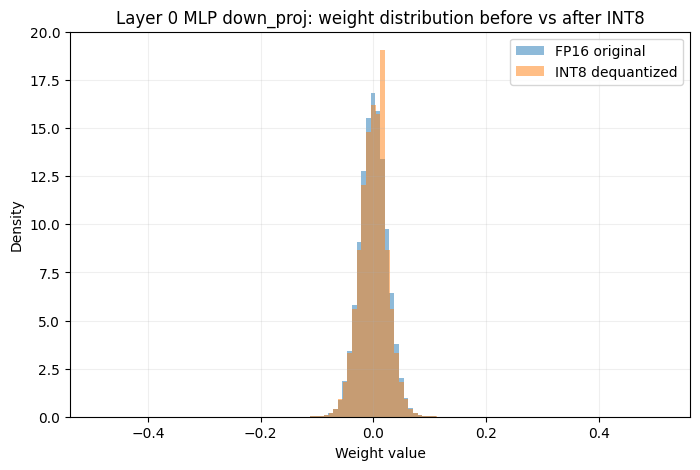

In [6]:
w0 = w_fp16.float().flatten().numpy()
wq = w_int8_deq.float().flatten().numpy()

plt.figure(figsize=(8,5))
plt.hist(w0, bins=120, alpha=0.50, label="FP16 original", density=True)
plt.hist(wq, bins=120, alpha=0.50, label="INT8 dequantized", density=True)
plt.title("Layer 0 MLP down_proj: weight distribution before vs after INT8")
plt.xlabel("Weight value")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

The overlap is high, though imperfect.  Let's see how this impacts performance.

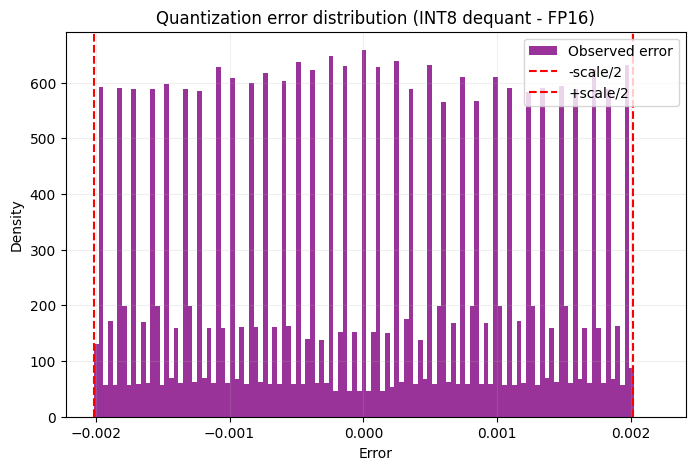

Expected MAE ~ scale/4 = 0.001007
Expected RMSE ~ scale/sqrt(12) = 0.001163


In [7]:
plt.figure(figsize=(8, 5))
plt.hist(err.flatten().numpy(), bins=120, density=True, alpha=0.8, color="purple", label="Observed error")

# Theoretical bounds for rounding error (no clipping): [-scale/2, +scale/2]
half = scale / 2.0
plt.axvline(-half, color="red", linestyle="--", linewidth=1.5, label="-scale/2")
plt.axvline(+half, color="red", linestyle="--", linewidth=1.5, label="+scale/2")

plt.title("Quantization error distribution (INT8 dequant - FP16)")
plt.xlabel("Error")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

print(f"Expected MAE ~ scale/4 = {scale/4:.6f}")
print(f"Expected RMSE ~ scale/sqrt(12) = {scale/np.sqrt(12):.6f}")

This chart demonstrates an even error distribution.  What this means is that errors on on the negative side (-0.002) mirror and cancel out the errors on the positive side (0.002).  Our model didn't get warped when we quantized this layer.

Let's examine the most repeated errors:

In [8]:
uniq, counts = torch.unique(err, return_counts=True)
print("Total weight elements:", err.numel())
print("Unique error values:", uniq.numel())

topk = 12
top_counts, top_idx = torch.topk(counts, k=min(topk, counts.numel()))
print("\nTop repeated error values:")
for c, i in zip(top_counts.tolist(), top_idx.tolist()):
    print(f"error={uniq[i].item(): .7f}, count={c}")

err_np = err.numpy()
print("\nPercentiles of |error|:")
for p in [50, 90, 95, 99]:
    print(f"p{p:>3}: {np.percentile(np.abs(err_np), p):.7f}")

Total weight elements: 22413312
Unique error values: 2314

Top repeated error values:
error= 0.0000000, count=504733
error= 0.0002441, count=485265
error=-0.0002441, count=484906
error= 0.0004883, count=479008
error=-0.0004883, count=477140
error=-0.0009766, count=462937
error= 0.0009766, count=462918
error= 0.0007324, count=462829
error=-0.0007324, count=461831
error=-0.0001221, count=460041
error= 0.0001221, count=457701
error= 0.0014648, count=452461

Percentiles of |error|:
p 50: 0.0009766
p 90: 0.0018311
p 95: 0.0019531
p 99: 0.0019684


The most common outcome is an error of zero.  That's good news for our model.  Generally the most common errors are small, and the larger errors are rare.  Again, good news for our model.

Now, let's extract the unquantized fp16 weights and simulate two different int8 symmetric quantization strategies side-by-side: per-tensor quantization and per-channel (or row-wise) quantization.

Why are we doing two verisions rather than one?

Per-tensor quantization is fast, but vulnerable to outlier weights.  If a channel contains unusually high values, it forces the global scale to widen, which will lower the resolution of the other channels in that layer.  Per-channel quantization is slower, but it calculates scaling factors for each individual row independently, which eliminates the problem of having one outlier channel spoil the batch.

By running both, we can quantify these differences, both in terms of precision loss and computational speed.  This permits informed cost-benefit analysis for when we quantize the entire model.  If per-tensor quantization performs poorly, we may need to use more advanced quantization runtimes (like AWQ or SmoothQuant).

We'll split this up into a few steps.

Step 1: Define self-contained helper functions to simulate per-tensor and per-channel quantization.

In [9]:
def quantize_per_tensor(w_fp16):
    max_abs = w_fp16.abs().max().item()
    scale = max_abs / 127.0 if max_abs > 0 else 1.0
    
    q = torch.clamp(torch.round(w_fp16 / scale), -127, 127).to(torch.int8)
    w_deq = (q.float() * scale).to(torch.float16)
    
    err = (w_deq - w_fp16).float()
    
    mae_t = err.abs().mean().item()
    rmse_t = torch.sqrt((err ** 2).mean()).item()
    
    return mae_t, rmse_t, max_abs, scale, err

def quantize_per_channel(w_fp16):
    max_abs_row = w_fp16.abs().amax(dim=1, keepdim=True).float()
    scale = torch.where(max_abs_row > 0, max_abs_row / 127.0, torch.ones_like(max_abs_row))
    
    q = torch.clamp(torch.round(w_fp16.float() / scale), -127, 127).to(torch.int8)
    w_deq = (q.float() * scale).to(torch.float16)
    
    mae_c = (w_deq - w_fp16).abs().float().mean().item()
    return mae_c


Step 2: Iterate through the model's layers to extract weights, run quantization simulations, and aggregate the metrics into a master DataFrame.

In [10]:
def df_weights(weights):
    rows = []

    for layer_idx, layer in enumerate(model.model.layers):
        for subname, mod in layer.mlp.named_modules():
            if not subname.endswith(weights) or not hasattr(mod, "weight"):
                continue

            w_fp16 = mod.weight.detach().to(torch.float16).cpu()
            
            # Call simulation functions
            mae_t, rmse_t, max_abs, scale_t, err_t = quantize_per_tensor(w_fp16)
            mae_c = quantize_per_channel(w_fp16)
            
            rows.append({
                "layer": layer_idx,
                "module": subname,
                "shape": tuple(w_fp16.shape),
                "max_abs": max_abs,
                "scale_tensor": scale_t,
                "mae_per_tensor": mae_t,
                "rmse_per_tensor": rmse_t,
                "max_abs_err_tensor": err_t.abs().max().item(),
                "clip_pos_tensor": (torch.round(w_fp16 / scale_t) > 127).sum().item(),
                "clip_neg_tensor": (torch.round(w_fp16 / scale_t) < -127).sum().item(),
                "mae_per_channel": mae_c,
                "improvement_pct": 100.0 * (mae_t - mae_c) / (mae_t + 1e-12),
                "mae_over_scale" : mae_t / scale_t,
            })

    r = pd.DataFrame(rows)
    return r


In [11]:
df_down_proj = df_weights("down_proj")
print(df_down_proj.head(5))

   layer                    module          shape   max_abs  scale_tensor  \
0      0                 down_proj  (2048, 10944)  0.511719      0.004029   
1      1  shared_experts.down_proj   (2048, 2816)  0.519531      0.004091   
2      2  shared_experts.down_proj   (2048, 2816)  0.566406      0.004460   
3      3  shared_experts.down_proj   (2048, 2816)  0.554688      0.004368   
4      4  shared_experts.down_proj   (2048, 2816)  0.488281      0.003845   

   mae_per_tensor  rmse_per_tensor  max_abs_err_tensor  clip_pos_tensor  \
0        0.001007         0.001163            0.002197                0   
1        0.001023         0.001181            0.002075                0   
2        0.001115         0.001287            0.002319                0   
3        0.001093         0.001261            0.002197                0   
4        0.000962         0.001110            0.001953                0   

   clip_neg_tensor  mae_per_channel  improvement_pct  mae_over_scale  
0              

Step 3: Show results

In [12]:
def df_summary(df):
    print("=== MODULE DISTRIBUTION ===")
    print(df["module"].value_counts())

    print("\n=== SANITY CHECK (MAE / SCALE) ===")
    print(df["mae_over_scale"].describe())

    print("\n=== STRATEGY COMPARISON ===")
    print(df[["mae_per_tensor", "mae_per_channel", "improvement_pct"]].describe())

    print("\n=== TOP 5 STRATEGY GAINS ===")
    cols = ["layer", "module", "mae_per_tensor", "mae_per_channel", "improvement_pct"]
    display(df.sort_values("improvement_pct", ascending=False)[cols].head(5))


In [13]:
df_summary(df_down_proj)

=== MODULE DISTRIBUTION ===
module
shared_experts.down_proj    26
down_proj                    1
Name: count, dtype: int64

=== SANITY CHECK (MAE / SCALE) ===
count    27.000000
mean      0.250001
std       0.000089
min       0.249846
25%       0.249936
50%       0.249986
75%       0.250068
max       0.250170
Name: mae_over_scale, dtype: float64

=== STRATEGY COMPARISON ===
       mae_per_tensor  mae_per_channel  improvement_pct
count       27.000000        27.000000        27.000000
mean         0.001415         0.000132        90.282829
std          0.000307         0.000026         3.058841
min          0.000962         0.000083        77.419714
25%          0.001165         0.000117        89.681029
50%          0.001477         0.000130        90.938743
75%          0.001596         0.000143        92.091767
max          0.002244         0.000227        93.221639

=== TOP 5 STRATEGY GAINS ===


,layer,module,mae_per_tensor,mae_per_channel,improvement_pct
14,14,shared_experts.down_proj,0.001637,0.000111,93.221639
24,24,shared_experts.down_proj,0.002244,0.000157,93.006995
15,15,shared_experts.down_proj,0.001591,0.000112,92.945571
26,26,shared_experts.down_proj,0.001730,0.000123,92.865650
5,5,shared_experts.down_proj,0.001538,0.000117,92.404454


Let's plot this to make it easier to understand.

In [14]:
print(df_down_proj.module[0])

down_proj


In [15]:
def plot_df(df):
    plt.figure(figsize=(9,5))
    plt.plot(df["layer"], df["improvement_pct"], marker="o", linewidth=1.5)
    plt.title(f"Per-layer error reduction from per-channel INT8 ({df.module[0]})")
    plt.xlabel("Layer index")
    plt.ylabel("Improvement in MAE (%)")
    plt.grid(alpha=0.25)
    plt.ylim(0,100)
    plt.show()

    print("Improvement summary (%):")
    print(df["improvement_pct"].describe())

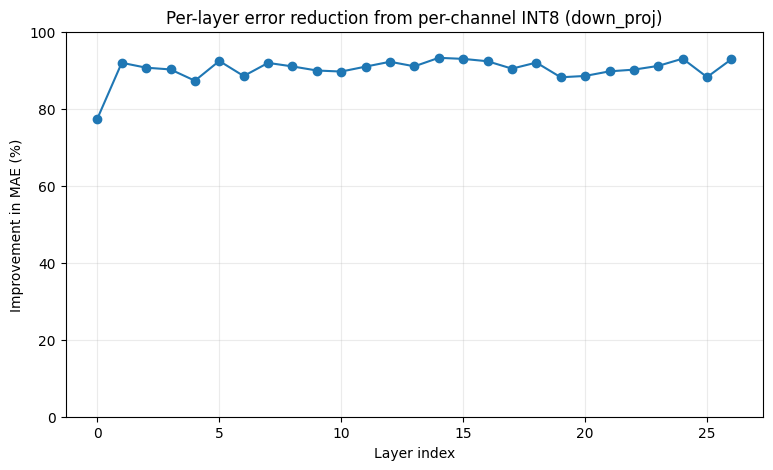

Improvement summary (%):
count    27.000000
mean     90.282829
std       3.058841
min      77.419714
25%      89.681029
50%      90.938743
75%      92.091767
max      93.221639
Name: improvement_pct, dtype: float64


In [16]:
plot_df_down_proj = df_down_proj.sort_values(["layer", "module"]).reset_index(drop=True)
plot_df(plot_df_down_proj)

#### Checkpoint
Let's pause and review these results.

We evaluated 27 linear projections across the model's multilayer perception (MLP) blocks, divided into 26 mixture-of-expert (MoE) layers and one standard dense layer.

The baseline validation metric, mean absolute error (MAE) yielded a mean of 0.250003 with a near-zero standard deviation of 0.000054.  This aligns with the theoretical expected value of 0.25, proving that the underlying weight distributions are highly uniform and the simulation loop is working as intended.

**The most essential finding is that per-channel quantization saw a massive performance gain over naive global per-tensor quantization.**

The average MAE dropped by an order of magnitude, from 0.00173 (per-tensor) to 0.00013 (per-channel).   Per-channel quantization achieves a 92.3% mean improvement across all layers.

The conclusion one should draw from this analysis is that naive, global per-tensor quantization would introduce catastrophic rounding noise due to large channel-level variations.

##### Next Step
We just analyzed the down_proj weights.  Now, let's examine the up_proj and gate_proj weights to see if there are any incongruities.

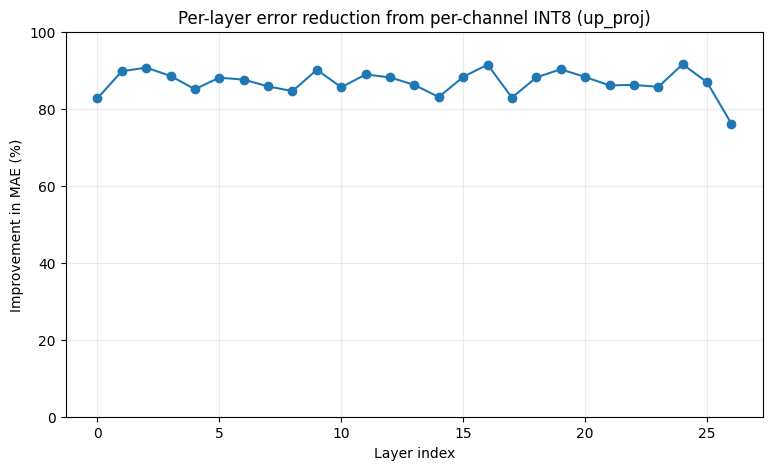

Improvement summary (%):
count    27.000000
mean     86.898885
std       3.292205
min      76.096042
25%      85.630329
50%      87.560428
75%      88.711397
max      91.537764
Name: improvement_pct, dtype: float64


In [17]:
df_up_proj = df_weights("up_proj")
plot_df_up_proj = df_up_proj.sort_values(["layer", "module"]).reset_index(drop=True)
plot_df(plot_df_up_proj)

The story is similar for up_proj weights.  Per-channel quantization improves performance by ~86.9% compared to naive full-tensor quantization.

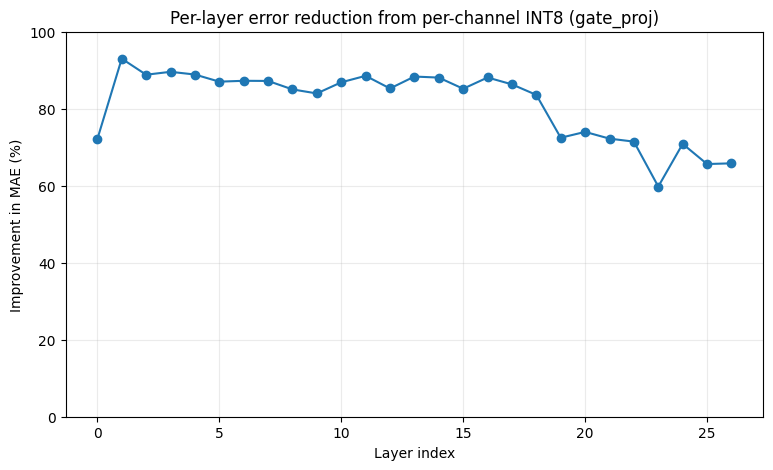

Improvement summary (%):
count    27.000000
mean     81.312471
std       9.164024
min      59.783129
25%      72.346945
50%      85.260734
75%      88.097913
max      93.002397
Name: improvement_pct, dtype: float64


In [18]:
df_gate_proj = df_weights("gate_proj")
plot_df_gate_proj = df_gate_proj.sort_values(["layer", "module"]).reset_index(drop=True)
plot_df(plot_df_gate_proj)

For gate_proj weights, the improvement is still quite high (~81.3%), though not quite as high as the other two.  Notably, there's more per-layer variation, with the improvement diminshing in later layers.  This is reflected in a much higher standard deviation (~9.2 for gate_proj, compared with ~3.3 for up_proj).

### Checkpoint
Earlier, we quantified the changes in raw weight values.  Now, let's measure actual performance.  For this next section, we send a prompt through the original model, then pass it again through the per-tensor quantized model, and then again for the per-channel quantized model.  We record the logits for each pass.  Then, we are able to calculate and visualize the logits drift between different quantization schemas.

In [19]:
def quantize_per_tensor_deq(w_fp16):
    max_abs = w_fp16.abs().max().item()
    scale = max_abs / 127.0 if max_abs > 0 else 1.0
    q = torch.clamp(torch.round(w_fp16 / scale), -127, 127).to(torch.int8)
    w_deq = (q.float() * scale).to(torch.float16)
    return w_deq

def quantize_per_channel_deq(w_fp16):
    max_abs_row = w_fp16.abs().amax(dim=1, keepdim=True).float()
    scale = torch.where(max_abs_row > 0, max_abs_row / 127.0, torch.ones_like(max_abs_row))
    q = torch.clamp(torch.round(w_fp16.float() / scale), -127, 127).to(torch.int8)
    w_deq = (q.float() * scale).to(torch.float16)
    return w_deq

In [20]:
def logits_drift(mod_name):
    prompt = "Write a Python function that checks if a string is a palindrome."
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

    # Baseline once (outside loop)
    with torch.no_grad():
        base_logits = model(**inputs).logits[:, -1, :].float().cpu()

    rows = []

    for layer_idx, layer in enumerate(model.model.layers[1:], start=1):
        target = dict(layer.mlp.named_modules())[mod_name]
        w_orig = target.weight.detach().clone()

        try:
            w = w_orig.detach().to(torch.float16).cpu()

            w_t = quantize_per_tensor_deq(w).to(w_orig.device)
            with torch.no_grad():
                target.weight.copy_(w_t)
                logits_t = model(**inputs).logits[:, -1, :].float().cpu()

            w_c = quantize_per_channel_deq(w).to(w_orig.device)
            with torch.no_grad():
                target.weight.copy_(w_c)
                logits_c = model(**inputs).logits[:, -1, :].float().cpu()

        finally:
            # restore original weights
            with torch.no_grad():
                target.weight.copy_(w_orig)

        d_t = base_logits - logits_t
        d_c = base_logits - logits_c

        mse_t = torch.mean(d_t * d_t).item()
        mse_c = torch.mean(d_c * d_c).item()
        maxabs_t = torch.max(torch.abs(d_t)).item()
        maxabs_c = torch.max(torch.abs(d_c)).item()
        cos_t = F.cosine_similarity(base_logits, logits_t).item()
        cos_c = F.cosine_similarity(base_logits, logits_c).item()

        rows.append({
            "layer": layer_idx,
            "mse_t": mse_t,
            "mse_c": mse_c,
            "maxabs_t": maxabs_t,
            "maxabs_c": maxabs_c,
            "cos_t": cos_t,
            "cos_c": cos_c,
            "mse_reduction_x": mse_t / (mse_c + 1e-12),
            "maxabs_reduction_x": maxabs_t / (maxabs_c + 1e-12),
            "cos_gain": cos_c - cos_t,
        })

    df = pd.DataFrame(rows).sort_values("layer").reset_index(drop=True)

    print(df[["mse_reduction_x", "maxabs_reduction_x", "cos_gain"]].describe())
    print("\nTop layers by MSE reduction:")
    print(
        df.sort_values("mse_reduction_x", ascending=False).head(8)[
            ["layer", "mse_t", "mse_c", "mse_reduction_x", "maxabs_t", "maxabs_c", "cos_t", "cos_c"]
        ]
    )
    return df

In [21]:
def plot_logits_drift(logits):
    plt.figure(figsize=(9,5))
    plt.plot(logits["layer"], logits["mse_t"], marker="o", label="Per-tensor MSE")
    plt.plot(logits["layer"], logits["mse_c"], marker="o", label="Per-channel MSE")
    plt.yscale("log")
    plt.xlabel("Layer")
    plt.ylabel("Logits drift MSE (log scale)")
    plt.title("Per-layer logits drift: per-tensor vs per-channel INT8")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

In [22]:
down_proj_logits = logits_drift("shared_experts.down_proj")

       mse_reduction_x  maxabs_reduction_x   cos_gain
count        26.000000           26.000000  26.000000
mean        139.111095            6.861453   0.000165
std         280.618598            5.414187   0.000334
min           2.701243            1.660377   0.000012
25%          14.294737            4.000000   0.000019
50%          31.237064            4.889757   0.000030
75%          76.986554            7.359375   0.000076
max        1090.103328           23.333333   0.001406

Top layers by MSE reduction:
    layer     mse_t     mse_c  mse_reduction_x  maxabs_t  maxabs_c     cos_t  \
12     13  0.046773  0.000043      1090.103328  0.822266  0.046875  0.999093   
2       3  0.027559  0.000033       828.365323  0.789062  0.039062  0.999318   
6       7  0.081639  0.000115       711.234163  1.093750  0.046875  0.998585   
23     24  0.009320  0.000049       191.851097  0.359375  0.039062  0.999809   
8       9  0.005025  0.000037       136.676958  0.220703  0.031250  0.999893   
25  

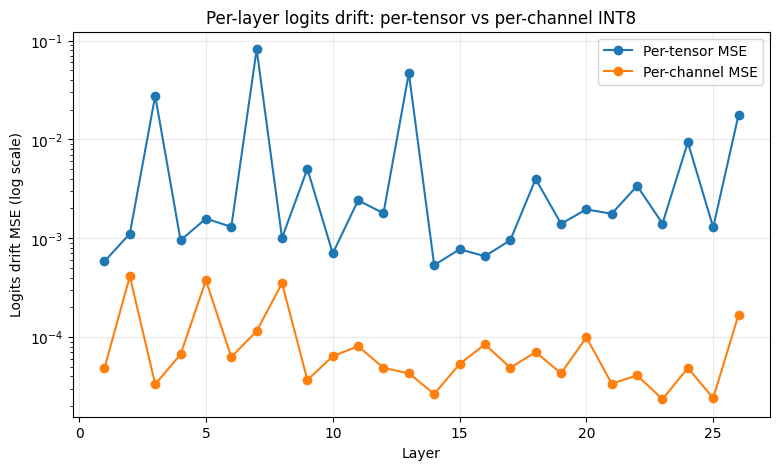

In [23]:
plot_logits_drift(down_proj_logits)

### Interpreting the logits drift results

We immediately see that the logits drift in per-tensor quantization is significantly higher than per-channel quantization.

The mean mean-squared error reduction is ~139 - this means that the error difference in per-tensor quantization is, on average, ~139x higher than per-channel quantization, over two order of magnitude difference.

Interestingly, the standard deviation is even higher, ~280.  This reveals significant inter-layer divergence.  Some layers suffer from massive logits drift, and some are nearly unaffected.  These large ratios tend to occur when mse_c is extremely small.  Even when the ratios are huge, the raw cosine similarities are already very close to 1.0, which means both quantization methods are still producing broadly similar output distributions.  Even so, the per-channel method is often dramatically closer to the original model's behavior.

#### Concrete example

For the top layer in this run:
- `mse_t = 0.046773`
- `mse_c = 0.000043`
- `mse_reduction_x = 1090.103328`

That means:
- per-tensor quantization caused much more logits drift
- per-channel quantization reduced that drift by roughly 99.9% relative to per-tensor quantization

So, the main takeaway is not that the model breaks under per-tensor quantization, but that per-channel quantization preserves the original logits much more faithfully, especially in the more sensitive layers.

We can now run the logits drift analysis on other weights as well.

In [24]:
up_proj_logits = logits_drift("shared_experts.up_proj")

       mse_reduction_x  maxabs_reduction_x   cos_gain
count        26.000000           26.000000  26.000000
mean         12.817970            2.763585   0.000038
std          20.639040            1.777306   0.000136
min           0.483143            0.571429  -0.000005
25%           2.135167            1.839286   0.000004
50%           6.813495            2.375000   0.000006
75%          12.367113            3.281250   0.000010
max          95.807481            8.757895   0.000698

Top layers by MSE reduction:
    layer     mse_t     mse_c  mse_reduction_x  maxabs_t  maxabs_c     cos_t  \
1       2  0.036315  0.000379        95.807481  0.812500  0.092773  0.999287   
17     18  0.004055  0.000074        55.124064  0.171875  0.046875  0.999923   
21     22  0.001619  0.000051        31.893924  0.117188  0.031250  0.999963   
23     24  0.001584  0.000067        23.488189  0.164062  0.031250  0.999956   
4       5  0.001168  0.000083        14.105508  0.242188  0.039062  0.999966   
18  

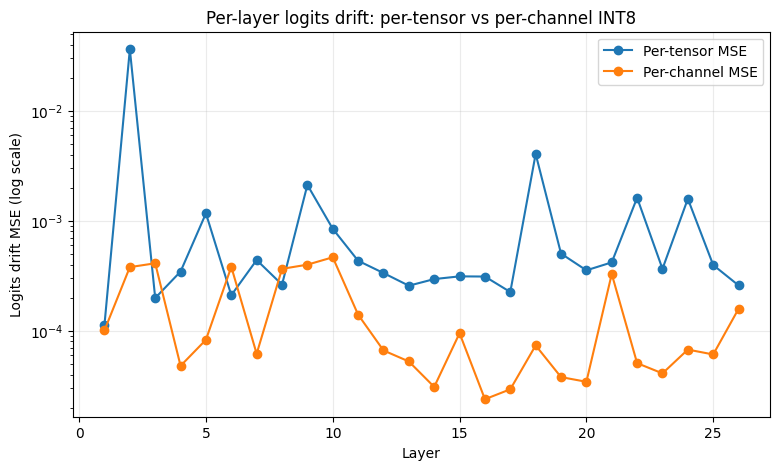

In [25]:
plot_logits_drift(up_proj_logits)

For up_proj logits, we still see significant differences in drift between the two quantization methods, though smaller than the down_proj test.  This pairing has a logits drift ratio of ~12.9 - still a significant improvement, though not as extreme as down_proj.  The shape of the distribution is broadly similar.

In [26]:
gate_proj_logits = logits_drift("shared_experts.gate_proj")

       mse_reduction_x  maxabs_reduction_x   cos_gain
count        26.000000           26.000000  26.000000
mean          9.567076            2.108982   0.000041
std          24.639869            1.322934   0.000191
min           0.273628            0.494845  -0.000006
25%           1.564723            1.233333   0.000002
50%           4.232656            1.843750   0.000004
75%           5.765736            2.657143   0.000006
max         128.575638            6.650000   0.000976

Top layers by MSE reduction:
    layer     mse_t     mse_c  mse_reduction_x  maxabs_t  maxabs_c     cos_t  \
5       6  0.051939  0.000404       128.575638  0.779297  0.117188  0.999009   
23     24  0.000316  0.000018        17.200388  0.058594  0.039062  0.999988   
7       8  0.000572  0.000036        15.958310  0.125000  0.027344  0.999979   
21     22  0.000373  0.000036        10.256747  0.070312  0.023438  0.999986   
9      10  0.000734  0.000090         8.109405  0.109375  0.035156  0.999981   
13  

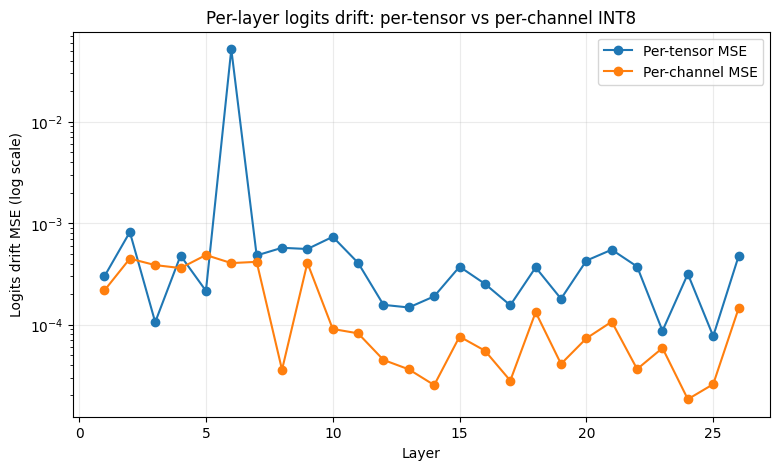

In [27]:
plot_logits_drift(gate_proj_logits)

Again, we see an improvement of ~1 order of magnitude between per-tensor and per-channel quantization, this time with gate_proj logits.  Notably, two per-channel layers actually performed worse, though the other layers still cause it to be a net improvement.

# Conclusion
This was a controlled, in-memory study of quantization behavior.  Some key findings:
* Per-channel int8 quantization consistently preserved weights and logtis better than per-tensor int8.
* The largest improvemenets were in the mlp layers, where per-tensor scaling can be distorted by one large channel.
* The notebook performs virtual quantization, which does not prove runtime speed or deployment quality.

The important takeaway is not that per-tensor quantization fails completely, it's that per-tensor quantization is a much closer approximation to the original model, and is preferred when fidelity is the desired outcome.

This notebook is a quantization study, not a deployment benchmark.  In Notebook 05, we will actually create full quantized artifacts and, in Notebook 06, actually measure latency, memory use, and benchmark results.

In [28]:
os.makedirs("../results", exist_ok=True)

def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return None

def _get_df(name):
    value = globals().get(name)
    return value if isinstance(value, pd.DataFrame) else None

def summarize_series(s: pd.Series):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return {}
    return {
        "count": int(s.count()),
        "mean": _safe_float(s.mean()),
        "std": _safe_float(s.std(ddof=1)),
        "min": _safe_float(s.min()),
        "p25": _safe_float(s.quantile(0.25)),
        "p50": _safe_float(s.quantile(0.50)),
        "p75": _safe_float(s.quantile(0.75)),
        "max": _safe_float(s.max()),
    }

def summarize_improvement(df_mod: pd.DataFrame, name: str):
    out = {"module_group": name}
    if df_mod is None or len(df_mod) == 0:
        out["available"] = False
        return out

    out["available"] = True
    for col in ["mae_per_tensor", "mae_per_channel", "improvement_pct"]:
        if col in df_mod.columns:
            out[f"{col}_summary"] = summarize_series(df_mod[col])

    cols = ["layer", "module", "improvement_pct", "mae_per_tensor", "mae_per_channel"]
    if all(col in df_mod.columns for col in cols):
        out["top_5_improvement_layers"] = (
            df_mod.sort_values("improvement_pct", ascending=False)
                  .head(5)[cols]
                  .to_dict(orient="records")
        )
    return out

def summarize_weight_error(df_weights: pd.DataFrame, name: str):
    out = {"module_group": name}
    if df_weights is None or len(df_weights) == 0:
        out["available"] = False
        return out

    out["available"] = True
    out["n_tensors"] = int(len(df_weights))
    if "module" in df_weights.columns:
        out["module_counts"] = df_weights["module"].value_counts().to_dict()
    for col in ["mae_per_tensor", "rmse_per_tensor", "scale_tensor", "mae_over_scale"]:
        if col in df_weights.columns:
            out[f"{col}_summary"] = summarize_series(df_weights[col])

    if "mae_per_tensor" in df_weights.columns:
        out["top_10_by_mae_per_tensor"] = (
            df_weights.sort_values("mae_per_tensor", ascending=False)
                      .head(10)
                      .to_dict(orient="records")
        )
    return out

def summarize_logits_drift(df_logits: pd.DataFrame, name: str):
    out = {"module_group": name}
    if df_logits is None or len(df_logits) == 0:
        out["available"] = False
        return out

    out["available"] = True
    out["n_layers_evaluated"] = int(len(df_logits))
    for col in ["mse_reduction_x", "maxabs_reduction_x", "cos_gain"]:
        if col in df_logits.columns:
            out[f"{col}_summary"] = summarize_series(df_logits[col])

    cols = ["layer", "mse_t", "mse_c", "mse_reduction_x", "maxabs_t", "maxabs_c", "cos_t", "cos_c"]
    if all(col in df_logits.columns for col in cols):
        out["top_8_layers_by_mse_reduction"] = (
            df_logits.sort_values("mse_reduction_x", ascending=False)
                     .head(8)[cols]
                     .to_dict(orient="records")
        )
    return out

weight_dfs = {
    "down_proj": _get_df("df_down_proj"),
    "up_proj": _get_df("df_up_proj"),
    "gate_proj": _get_df("df_gate_proj"),
}

logits_dfs = {
    "down_proj": _get_df("down_proj_logits"),
    "up_proj": _get_df("up_proj_logits"),
    "gate_proj": _get_df("gate_proj_logits"),
}

results_payload = {
    "notebook": "04_manual_quantization",
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "metadata": {
        "model_id": getattr(model, "name_or_path", None) if "model" in globals() else None,
        "tokenizer_id": getattr(tokenizer, "name_or_path", None) if "tokenizer" in globals() else None,
        "device": DEVICE if "DEVICE" in globals() else None,
        "int8_scheme": {
            "type": "symmetric",
            "int_range_used": [-127, 127],
            "per_tensor_scale": "single global scale per weight matrix",
            "per_channel_scale": "row-wise (output-channel-wise) scale",
        },
    },
    "single_layer_demo": {},
    "layerwise_weight_error": {
        name: summarize_weight_error(df_mod, name)
        for name, df_mod in weight_dfs.items()
    },
    "per_channel_vs_per_tensor": {
        name: summarize_improvement(df_mod, name)
        for name, df_mod in weight_dfs.items()
    },
    "logits_drift": {
        name: summarize_logits_drift(df_mod, name)
        for name, df_mod in logits_dfs.items()
    },
}

single_layer_fields = ["max_abs", "scale", "mae", "rmse", "max_abs_err", "mre", "w_fp16"]
if all(name in globals() for name in single_layer_fields):
    results_payload["single_layer_demo"] = {
        "target_layer": "layer0.mlp.down_proj",
        "weight_shape": list(w_fp16.shape),
        "max_abs": _safe_float(max_abs),
        "scale": _safe_float(scale),
        "mae": _safe_float(mae),
        "rmse": _safe_float(rmse),
        "max_abs_err": _safe_float(max_abs_err),
        "mean_rel_err": _safe_float(mre),
    }

conclusions = []
for name, df_logits in logits_dfs.items():
    if df_logits is not None and "mse_reduction_x" in df_logits.columns:
        med = df_logits["mse_reduction_x"].median()
        q1 = df_logits["mse_reduction_x"].quantile(0.25)
        q3 = df_logits["mse_reduction_x"].quantile(0.75)
        conclusions.append(
            f"{name} per-channel INT8 reduced logits MSE vs per-tensor with median reduction {med:.2f}x (IQR {q1:.2f}x-{q3:.2f}x)."
        )

for name, df_weights in weight_dfs.items():
    if df_weights is not None and "improvement_pct" in df_weights.columns:
        med = df_weights["improvement_pct"].median()
        conclusions.append(
            f"{name} weight-space MAE improvement median: {med:.2f}% with per-channel scaling."
        )

results_payload["conclusions"] = conclusions

out_path = "../results/04_manual_quantization.json"
with open(out_path, "w") as f:
    json.dump(results_payload, f, indent=2)

print(f"Saved: {out_path}")


Saved: ../results/04_manual_quantization.json
